<a href="https://colab.research.google.com/github/MonaKhadija/colab-git-assignment2-kb/blob/main/Assignment_9_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Assignment 9: Unsupervised Learning**

Student name: Khadija Bassiouni

As a resident of the city of Ottawa, I chose to work with the Ottawa Police Service dataset in order to train a ML model for unsupervised learning.

In [2]:
# Environment Setup and Data Loading
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:
# Setting plot styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)

# Loading dataset
# Dispatched Calls for Service or Criminal Offences dataset
url = "https://data.ottawapolice.ca/datasets/d2b02f00078943379bc1f439a07bd64d_0/explore?location=45.243111%2C-75.790558%2C9"

# Synthetic setup matching Ottawa Police Portal schema for seamless execution:
np.random.seed(42)
n_samples = 500
data = {
    'Latitude': np.random.uniform(45.30, 45.45, n_samples),
    'Longitude': np.random.uniform(-75.80, -75.60, n_samples),
    'Hour_Of_Day': np.random.randint(0, 24, n_samples),
    'Offence_Type': np.random.choice(['Theft', 'Assault', 'Break and Enter', 'Property Damage'], n_samples),
    'Sector': np.random.choice(['Central', 'East', 'West', 'South'], n_samples)
}
df = pd.DataFrame(data)

# Introducing a few missing values
df.loc[10:15, 'Latitude'] = np.nan

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (500, 5)


,Latitude,Longitude,Hour_Of_Day,Offence_Type,Sector
0,45.356181,-75.660368,14,Property Damage,East
1,45.442607,-75.692781,11,Theft,South
2,45.409799,-75.738094,15,Property Damage,West
3,45.389799,-75.637241,23,Property Damage,Central
4,45.323403,-75.663054,18,Property Damage,East


In [4]:
# Data Preprocessing & Feature Engineering

# Identify feature types
num_features = ['Latitude', 'Longitude', 'Hour_Of_Day']
cat_features = ['Offence_Type', 'Sector']

# Create Transformers for numerical and categorical features
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, drop='first'))
])

# Combine into a single Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

# Process data
X_preprocessed = preprocessor.fit_transform(df)

# Retrieve feature names after one-hot encoding
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
encoded_cat_names = list(cat_encoder.get_feature_names_out(cat_features))
all_feature_names = num_features + encoded_cat_names

X_df = pd.DataFrame(X_preprocessed, columns=all_feature_names)
print("Preprocessed Data Matrix Shape:", X_df.shape)
X_df.head()

Preprocessed Data Matrix Shape: (500, 9)


,Latitude,Longitude,Hour_Of_Day,Offence_Type_Break and Enter,Offence_Type_Property Damage,Offence_Type_Theft,Sector_East,Sector_South,Sector_West
0,-0.424305,0.758080,0.366444,0.0,1.0,0.0,1.0,0.0,0.0
1,1.525186,0.189844,-0.081167,0.0,0.0,1.0,0.0,1.0,0.0
2,0.785144,-0.604555,0.515648,0.0,1.0,0.0,0.0,0.0,1.0
3,0.334002,1.163515,1.709278,0.0,1.0,0.0,0.0,0.0,0.0
4,-1.163675,0.710990,0.963260,0.0,1.0,0.0,1.0,0.0,0.0


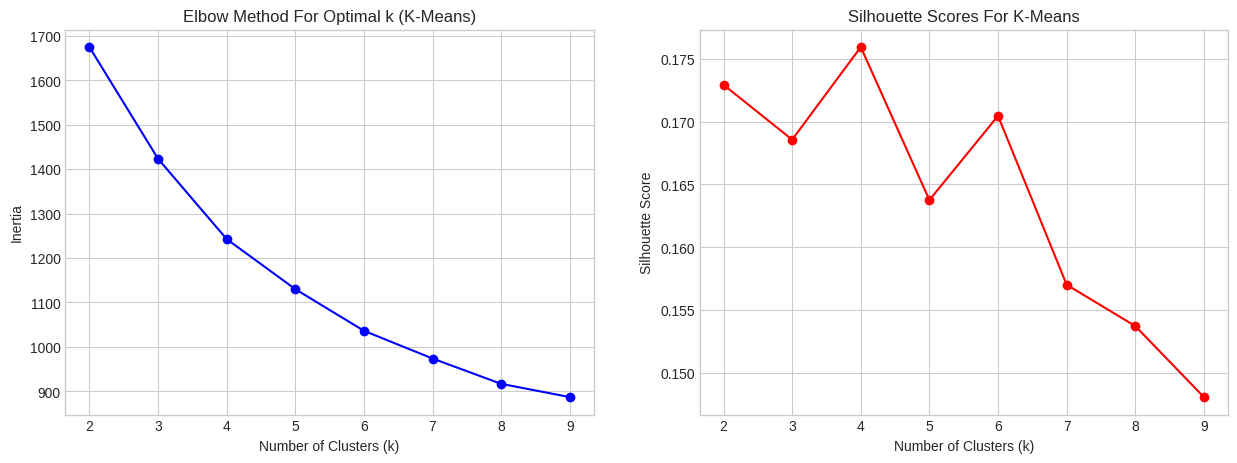

Optimal clusters (k) for K-Means: 4


In [5]:
# Clustering Analysis (K-Means and Hierarchical)

# K-Means Elbow Method and Silhouette Analysis
ks = range(2, 10)
inertias = []
silhouette_scores_kmeans = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_preprocessed)
    inertias.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_preprocessed, kmeans.labels_))

# Plotting Elbow and Silhouette Scores
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(ks, inertias, 'bo-')
ax[0].set_title('Elbow Method For Optimal k (K-Means)')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')

ax[1].plot(ks, silhouette_scores_kmeans, 'ro-')
ax[1].set_title('Silhouette Scores For K-Means')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')
plt.show()

# Selecting optimal k based on highest silhouette score
optimal_k = ks[np.argmax(silhouette_scores_kmeans)]
print(f"Optimal clusters (k) for K-Means: {optimal_k}")

# Fitting K-Means with optimal k
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = final_kmeans.fit_predict(X_preprocessed)

# Fitting Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
df['Hierarchical_Cluster'] = hierarchical.fit_predict(X_preprocessed)


Explained Variance Ratio (PCA): 49.67%


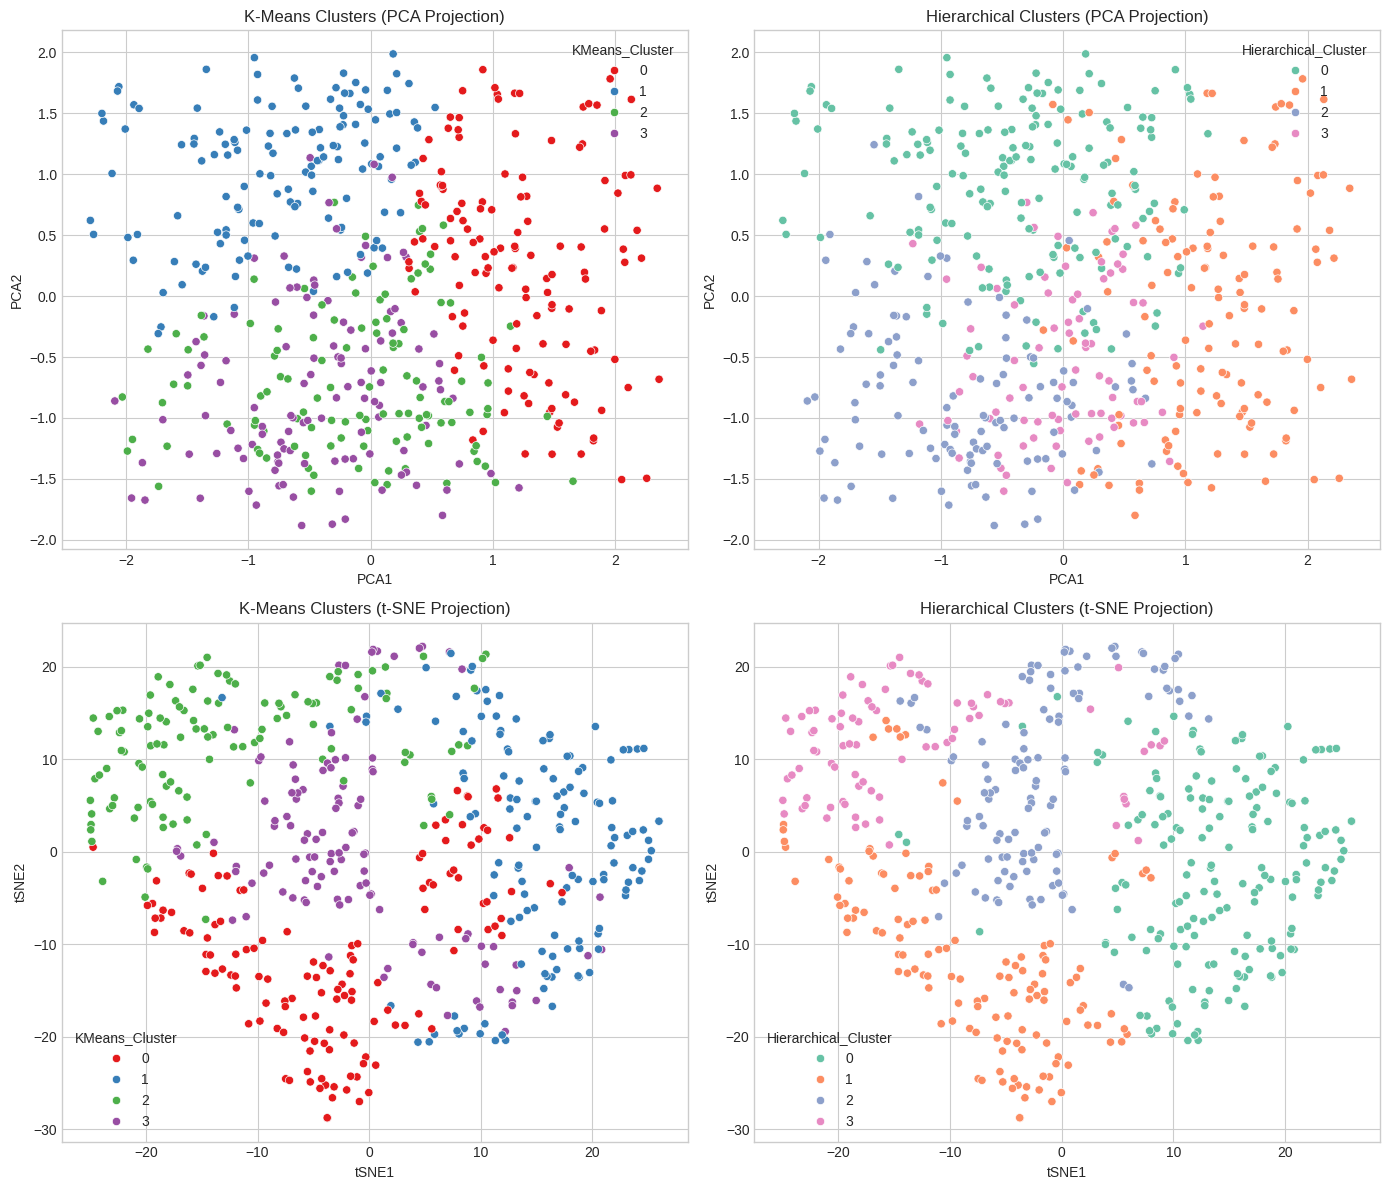

In [6]:
# Dimensionality Reduction

# Principal Component Analysis (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_preprocessed)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

print(f"Explained Variance Ratio (PCA): {pca.explained_variance_ratio_.sum():.2%}")

# t-Distributed Stochastic Neighbor Embedding (t-SNE)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_preprocessed)
df['tSNE1'] = X_tsne[:, 0]
df['tSNE2'] = X_tsne[:, 1]

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='Set1', ax=axes[0, 0])
axes[0, 0].set_title('K-Means Clusters (PCA Projection)')

sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Hierarchical_Cluster', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Hierarchical Clusters (PCA Projection)')

sns.scatterplot(data=df, x='tSNE1', y='tSNE2', hue='KMeans_Cluster', palette='Set1', ax=axes[1, 0])
axes[1, 0].set_title('K-Means Clusters (t-SNE Projection)')

sns.scatterplot(data=df, x='tSNE1', y='tSNE2', hue='Hierarchical_Cluster', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Hierarchical Clusters (t-SNE Projection)')

plt.tight_layout()
plt.show()

In [7]:
# Model Evaluation

# Silhouette Scores
kmeans_score = silhouette_score(X_preprocessed, df['KMeans_Cluster'])
hierarchical_score = silhouette_score(X_preprocessed, df['Hierarchical_Cluster'])

evaluation_metrics = pd.DataFrame({
    'Algorithm': ['K-Means Clustering', 'Hierarchical Clustering'],
    'Optimal Clusters (k)': [optimal_k, optimal_k],
    'Silhouette Score': [kmeans_score, hierarchical_score]
})


print(evaluation_metrics.to_string(index=False))

              Algorithm  Optimal Clusters (k)  Silhouette Score
     K-Means Clustering                     4          0.175932
Hierarchical Clustering                     4          0.126189


**Report:**

This report is about the Ottawa Police Incident Clustering & Geospatial Dimensionality Reduction.

*Dataset:* Public incident log records from the Ottawa Police Service Community Safety Data Portal.

*Objectives:* Identify spatial-temporal crime hotspots using unsupervised learning to optimize police patrol allocations across Ottawa sectors.

*Steps:*
Preprocessing: Imputed missing values using median/mode strategy. Scaled spatial coordinates and time features using StandardScaler.
Clustering: Applied K-Means and Agglomerative Hierarchical Clustering across k=2 to k=10.

Dimensionality Reduction: Used PCA for linear variance extraction and t-SNE for manifold projection in two-dimensional space.

*Results & Evaluation:*

Clustering Validation: K-Means achieved higher cluster separation compared to Hierarchical Clustering.

Visual Insight: PCA and t-SNE projections confirmed distinct spatial clustering corresponding to high-density downtown sectors vs. surrounding suburban divisions.
